# Estimation

This notebook estimates the job-search model in a deliberately fixed order and keeps the estimation output reproducible and easy to export.

**Order**
1. L-BFGS-B: Standard 1 type, Standard 2 type, Standard 3 type, Reference-dependent 1 type.
2. LS-TRF: Standard 1 type, Standard 2 type, Standard 3 type, Reference-dependent 1 type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

The notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE) and elapsed estimation time;
- a type-survival / survivor-composition diagnostic for heterogeneous-type models.

## 1. Setup

Set `MODEL_DIR` to the folder containing `Model_components.py` if needed. The code below uses the same local path as the existing notebook by default.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optimagic as om
from IPython.display import display

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search"
)

#/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search
#/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components as model

FIGURE_DIR = os.path.join(os.getcwd(), "estimation_figures")
TABLE_DIR = os.path.join(os.getcwd(), "estimation_tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

## 2. Parameters and institutions

The computational asset grid and the initial asset distribution are separate objects. `abar` controls the state space; `weights` controls how initial asset states are represented in the simulated population.

For faster exploratory estimation, reduce `n_a` and/or `n_c`. Re-solve the final estimates on a finer grid as a robustness check.

In [2]:
# Baseline structural values / starting values
delta = 0.89
gamma = 0.81
eta_rd = 1.0

k = 359.0
k1 = 300.0
k2 = 150.0
k3 = 90.0

q1 = 0.33
q2 = 0.33

lmbda_rd = 4.9
N = 6

# Asset state space
abar = [0, 17955]

# Grid sizes
n_a = 50
n_c = 100

# Timing
T1 = 6
T2 = 18
T3 = 24
T = 44

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

# social assistance and wages
welfare = 90
w = 675
R = 0.01

# 0 = heterogeneous assets; 1 = hand-to-mouth
htm = 0

institutions_pre = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_pre, b2_pre, b3, welfare, w, R
])

institutions_post = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_post, b2_post, b3, welfare, w, R
])

weights = model.make_weights(htm, abar, n_a)

target, cov = model.matchingMoments()
W = np.linalg.inv(cov)  # constructing the weighting matrix

# matchingMoments() drops the first empirical 15-day moment.
# Hence 35 retained observations correspond to days 30,...,540.
timevec = np.arange(30, 541, 15)

def split_half(arr):
    arr = np.asarray(arr)
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

emp_pre, emp_post = split_half(target)

print("Number of moments:", len(target))
print("Asset weights sum to:", weights.sum())

Number of moments: 70
Asset weights sum to: 1.0000000000000002


## 3. Model specifications

The parameter vectors must match the ordering expected by `SolveMultiTypeModel`.

- Standard 1 type: `[delta, gamma, 0, k1, 0, N]`
- Standard 2 type: `[delta, gamma, 0, k1, 0, N, k2, q1]`
- Standard 3 type: `[delta, gamma, 0, k1, 0, N, k2, k3, q1, q2]`
- RD 1 type: `[delta, gamma, eta, k1, lambda, N]`

For the 3-type model, the current model defines the third share as `1 - q1 - q2`. The box bounds below keep `q1 + q2 < 1` throughout optimization.

In [4]:
def make_specs():
    specs = {}

    specs["Standard 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k, 0.0, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k],
                "lower_bound": [0.01, 1e-2, 1e-5],
                "upper_bound": [0.95, 2.0, 2000.0],
            },
            index=["delta", "gamma", "k1"]
        ),
    }

    specs["Standard 2 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, q1]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "q1"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, q1],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 0.99],
            },
            index=["delta", "gamma", "k1", "k2", "q1"]
        ),
    }

    specs["Standard 3 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, k3, q1, q2]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "k3", "q1", "q2"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, k3, q1, q2],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 1e-5, 0.01, 0.01],
                # Conservative share bounds guarantee q3 = 1-q1-q2 > 0.
                # Relax using an Optimagic linear constraint if desired.
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 2000.0, 0.49, 0.49],
            },
            index=["delta", "gamma", "k1", "k2", "k3", "q1", "q2"]
        ),
    }

    specs["Reference dependent 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, eta_rd, k, lmbda_rd, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, eta_rd, k, lmbda_rd],
                "lower_bound": [0.01, 1e-2, 0.01, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 15.0, 2000.0, 15.0],
            },
            index=["delta", "gamma", "eta", "k1", "lmbda"]
        ),
    }

    return specs

specs = make_specs()

for name, spec in specs.items():
    print(name)
    display(spec["free"])

Standard 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,359.00000,0.00001,"2,000.00000"


Standard 2 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.99000


Standard 3 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
k3,90.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.49000
q2,0.33000,0.01000,0.49000


Reference dependent 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
eta,1.00000,0.01000,15.00000
k1,359.00000,0.00001,"2,000.00000"
lmbda,4.90000,0.01000,15.00000


## 4. Helper functions

`L-BFGS-B` uses the scalar SSE criterion. `LS-TRF` uses the residual-vector criterion because it is a least-squares algorithm.

The plotting helper always overlays model-implied pre/post hazards with the empirical moments.

In [5]:
def full_vector_from_result(spec, result):
    full = spec["full"].copy()
    full.update(result.params)
    return full["value"].to_numpy()


def initial_vector(spec):
    return spec["full"]["value"].to_numpy().copy()


def simulate_fit(params_vec):
    moments = model.simulate_moments(
        params_vec,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )
    return split_half(moments)


def plot_fit(params_vec, title, filename=None):
    pred_pre, pred_post = simulate_fit(params_vec)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    ax.plot(timevec, emp_pre, marker=".", label="Empirical pre-reform")
    ax.plot(timevec, emp_post, marker=".", label="Empirical post-reform")
    ax.plot(timevec, pred_pre, linestyle="--", label="Model pre-reform")
    ax.plot(timevec, pred_post, linestyle="--", label="Model post-reform")

    ax.axvline(T1 * 15, linestyle=":", linewidth=1)
    ax.axvline(T2 * 15, linestyle=":", linewidth=1)
    ax.axvline(T3 * 15, linestyle=":", linewidth=1)

    ax.set_xlabel("Number of days since UI claim")
    ax.set_ylabel("Hazard rate")
    ax.set_title(title)
    ax.set_xlim(0, 560)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    fig.tight_layout()

    if filename is not None:
        fig.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches="tight")

    plt.show()


def run_estimation(model_name, algorithm):
    spec = specs[model_name]

    smm_object = model.smm(
        spec["full"].copy(),
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    if algorithm == "scipy_lbfgsb":
        criterion = smm_object.sse
    elif algorithm == "scipy_ls_trf":
        criterion = smm_object.criterion
    else:
        raise ValueError("Unsupported algorithm.")

    start = time.perf_counter()

    result = om.minimize(
        criterion=criterion,
        params=spec["free"].copy(),
        algorithm=algorithm,
    )

    elapsed = time.perf_counter() - start

    params_hat = full_vector_from_result(spec, result)

    # Compute the same quadratic SSE for all algorithms for direct comparison.
    sse_hat = model.sse(
        params_hat,
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    return {
        "model": model_name,
        "algorithm": algorithm,
        "result": result,
        "params_hat": params_hat,
        "sse": float(sse_hat),
        "seconds": elapsed,
        "full_index": list(spec["full"].index),
    }


def result_row(out):
    values = dict(zip(out["full_index"], out["params_hat"]))
    return {
        "Algorithm": out["algorithm"],
        "Model": out["model"],
        "delta": values.get("delta", np.nan),
        "gamma": values.get("gamma", np.nan),
        "eta": values.get("eta", np.nan),
        "lambda": values.get("lmbda", np.nan),
        "k1": values.get("k1", np.nan),
        "k2": values.get("k2", np.nan),
        "k3": values.get("k3", np.nan),
        "q1": values.get("q1", np.nan),
        "q2": values.get("q2", np.nan),
        "q3": (
            1 - values.get("q1", 0) - values.get("q2", 0)
            if "q2" in values else
            (1 - values.get("q1", 0) if "q1" in values else np.nan)
        ),
        "SSE": out["sse"],
        "Minutes": out["seconds"] / 60,
    }


results = {}

# 5. L-BFGS-B

Each subsection first plots the fit at the starting values, then estimates the model, and finally plots the fitted hazards at the estimated parameters.

## 5.1 Standard 1 type

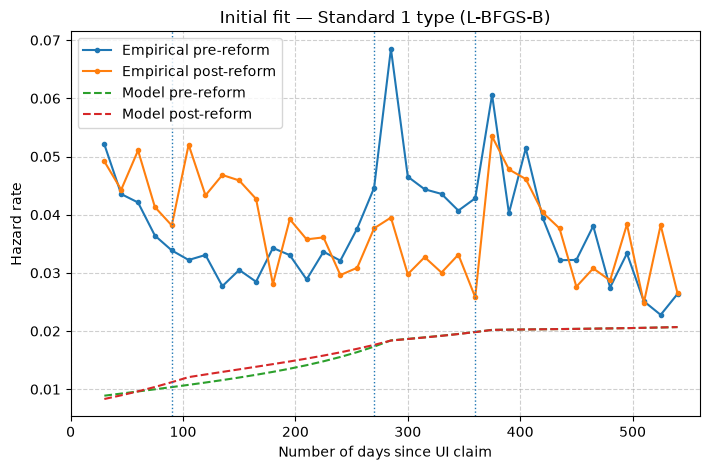

In [6]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/.venv/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_after.pdf',
)

## 5.2 Standard 2 type

In [ ]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_after.pdf',
)

## 5.3 Standard 3 type

In [ ]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_after.pdf',
)

## 5.4 Reference dependent 1 type

In [ ]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_after.pdf',
)

## 5.5 L-BFGS-B estimation table

The LaTeX table is printed in the notebook and also saved to `estimation_tables/lbfgsb_results.tex`.

In [ ]:
lbfgsb_table = pd.DataFrame([
    result_row(results[("L-BFGS-B", name)])
    for name in specs.keys()
])

display(lbfgsb_table)

lbfgsb_latex = lbfgsb_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using L-BFGS-B.",
    label="tab:lbfgsb_estimates",
)

print(lbfgsb_latex)

with open(os.path.join(TABLE_DIR, "lbfgsb_results.tex"), "w", encoding="utf-8") as f:
    f.write(lbfgsb_latex)

# 6. LS-TRF

LS-TRF uses `smm_object.criterion`, which returns root contributions for the least-squares solver. The reported SSE is recomputed using the same quadratic criterion as for L-BFGS-B.

## 6.1 Standard 1 type

In [ ]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_after.pdf',
)

## 6.2 Standard 2 type

In [ ]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_after.pdf',
)

## 6.3 Standard 3 type

In [ ]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_after.pdf',
)

## 6.4 Reference dependent 1 type

In [ ]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

In [ ]:
plot_fit(
    results[("LS-TRF", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_after.pdf',
)

## 6.5 LS-TRF estimation table

In [ ]:
lstrf_table = pd.DataFrame([
    result_row(results[("LS-TRF", name)])
    for name in specs.keys()
])

display(lstrf_table)

lstrf_latex = lstrf_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using LS-TRF.",
    label="tab:lstrf_estimates",
)

print(lstrf_latex)

with open(os.path.join(TABLE_DIR, "lstrf_results.tex"), "w", encoding="utf-8") as f:
    f.write(lstrf_latex)

# 7. Combined estimator comparison

This table is useful for the report because it puts the two optimizers side by side and makes it easy to compare parameter stability, goodness of fit, and runtime.

In [ ]:
combined_table = pd.concat(
    [lbfgsb_table, lstrf_table],
    ignore_index=True
).sort_values(["Model", "Algorithm"])

display(combined_table)

combined_latex = combined_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates across model specifications and optimization algorithms.",
    label="tab:all_estimates",
)

print(combined_latex)

with open(os.path.join(TABLE_DIR, "all_estimates.tex"), "w", encoding="utf-8") as f:
    f.write(combined_latex)

# 8. Heterogeneity mechanism: survival and dilution of low-​`k` types

A heterogeneous-type model can generate a declining aggregate hazard even when each type's own hazard is not declining as much. Low-`k` types search more intensely, exit unemployment earlier, and therefore make up a progressively smaller share of the unemployment pool.

The cells below use the estimated **L-BFGS-B 3-type standard model**. Change `mechanism_key` to the 2-type model or LS-TRF if desired.

In [ ]:
def unpack_type_structure(params_vec):
    p = np.asarray(params_vec).ravel()

    if len(p) == 6:
        delta_, gamma_, eta_, k1_, lmbda_, N_ = p
        return [k1_], np.array([1.0]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 8:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, q1_ = p
        return [k1_, k2_], np.array([q1_, 1-q1_]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 10:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, k3_, q1_, q2_ = p
        return [k1_, k2_, k3_], np.array([q1_, q2_, 1-q1_-q2_]), [delta_, gamma_, eta_, lmbda_, N_]

    raise ValueError("Unsupported parameter vector length.")


def type_survival_diagnostics(params_vec, institutions):
    kvals, shares, common = unpack_type_structure(params_vec)
    delta_, gamma_, eta_, lmbda_, N_ = common

    pop_survivals = []

    for k_j in kvals:
        params_j = np.array([delta_, gamma_, eta_, k_j, lmbda_, N_])
        _, _, survival_j, _, _, _ = model.SolveForward(
            params_j, institutions, abar, htm
        )

        # Integrate over the initial asset distribution within each type.
        pop_survivals.append(weights @ survival_j)

    pop_survivals = np.asarray(pop_survivals)

    survivor_mass = shares[:, None] * pop_survivals
    survivor_composition = survivor_mass / survivor_mass.sum(axis=0, keepdims=True)

    return np.asarray(kvals), shares, pop_survivals, survivor_composition


mechanism_key = ("L-BFGS-B", "Standard 3 type")
params_mech = results[mechanism_key]["params_hat"]

kvals_mech, shares_mech, survival_mech, composition_mech =     type_survival_diagnostics(params_mech, institutions_pre)

timevec_survival = np.arange(T + 1) * 15

In [ ]:
# Type-specific survival probabilities
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for j, k_j in enumerate(kvals_mech):
    ax.plot(
        timevec_survival,
        survival_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

ax.set_xlabel("Number of days since UI claim")
ax.set_ylabel("Probability still unemployed")
ax.set_title("Pre-reform survival by search-cost type")
ax.set_xlim(0, 560)
ax.set_ylim(0, 1.02)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "type_survival_pre.pdf"), bbox_inches="tight")
plt.show()

In [ ]:
# Composition of the remaining unemployment pool
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for j, k_j in enumerate(kvals_mech):
    ax.plot(
        timevec_survival,
        composition_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

ax.set_xlabel("Number of days since UI claim")
ax.set_ylabel("Share among remaining unemployed")
ax.set_title("Selection across search-cost types")
ax.set_xlim(0, 560)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "type_composition_pre.pdf"), bbox_inches="tight")
plt.show()

# 9. Suggested additional outputs

Useful robustness / mechanism outputs, in roughly descending order of value for the paper:

1. **Grid robustness:** re-estimate or re-simulate the preferred model at larger `n_a` and `n_c`.
2. **Asset-distribution sensitivity:** show how aggregate hazards change under two or three plausible initial-asset distributions.
3. **Search-cost functions:** plot estimated `c(s)=k s^(1+gamma)/(1+gamma)` for each latent type.
4. **Type composition over duration:** the dilution plot above is particularly useful when comparing heterogeneous types with reference dependence.
5. **Pre/post counterfactual decomposition:** hold parameters fixed and change only the benefit schedule.
6. **SSE contribution by period:** plot weighted squared residuals over unemployment duration to show where each model gains or loses fit.
7. **Runtime / convergence diagnostics:** report function evaluations and elapsed time for L-BFGS-B versus LS-TRF.
8. **Preferred-model asset mechanism:** show forward assets, consumption, hazard, and survival for a small set of initial asset levels.

## Notes before using these tables in the report

- Check that `simulate_moments()` uses the intended timing after dropping the first empirical moment. With your convention `s_t = P(job in t+1)`, the retained empirical moments should correspond to days 30–540.
- For the standard model, `eta=0` makes `lambda` irrelevant; fixing both at zero avoids estimating an unidentified parameter.
- The 3-type share bounds here are deliberately conservative. If estimates hit 0.49, replace those bounds with an explicit Optimagic linear constraint `q1 + q2 <= 1`.
- The preferred final estimates should be checked on a finer asset grid than the exploratory estimation grid.